In [2]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
import pandas as pd

data = pd.read_excel(r'G:\My Drive\AugSpectro-Share\Low-cost Spectrophotometer Data (Done)\Analysis\Sumdata.xlsx', sheet_name=r'Turbidity Data')

print (data)

filtered_data = data[data['Turbidity'] <= 300]

# List of site IDs to filter by
site_ids = ["PAK", "BB", "KWR", "TCI", "TCO"]

# Dictionary to hold the filtered data for each site
filtered_data_by_site = {}

# Loop through each site ID and filter the data accordingly
for site_id in site_ids:
    filtered_data_by_site[site_id] = filtered_data[filtered_data['SiteID'] == site_id]

# Now you can access the filtered data for each site using the dictionary
filtered_data_PAK = filtered_data_by_site["PAK"]
filtered_data_BB = filtered_data_by_site["BB"]
filtered_data_KWR = filtered_data_by_site["KWR"]
filtered_data_TCI = filtered_data_by_site["TCI"]
filtered_data_TCO = filtered_data_by_site["TCO"]
filtered_data_TC = pd.concat([filtered_data_by_site["TCI"], filtered_data_by_site["TCO"]], axis=0)
filtered_data_WW=pd.concat([
    filtered_data_by_site["PAK"], 
    filtered_data_by_site["BB"], 
    filtered_data_by_site["KWR"]
], axis=0)
filtered_data_Global = pd.concat([
    filtered_data_by_site["PAK"], 
    filtered_data_by_site["BB"], 
    filtered_data_by_site["KWR"], 
    filtered_data_by_site["TCI"], 
    filtered_data_by_site["TCO"]
], axis=0)

#Extract the data cube
Site = 'Global'
Parameter ='Turbidity'
unit_target = "NTU"

# Use eval to dynamically reference the variable for the site
X = eval(f"filtered_data_{Site}").iloc[:, :18].values
Y = eval(f"filtered_data_{Site}")[Parameter].values

# Wavelengths for the 18 channels
wavelengths = [410, 435, 465, 485, 510, 535, 560, 585, 610, 645, 680, 705, 730, 760, 810, 860, 900, 940]


n_readings_per_sample = 20
n_channels = 18  # Number of channels
n_samples = X.shape[0] // n_readings_per_sample  # Number of samples

# Initialize an array to store the averaged readings
averaged_readings = np.zeros((n_samples, n_channels))

# Calculate the average readings for each sample
for sample_index in range(n_samples):
    start_idx = sample_index * n_readings_per_sample
    end_idx = start_idx + n_readings_per_sample
    
    # Take the 20 readings for the current sample and compute the mean across axis 0 (for the channels)
    averaged_readings[sample_index, :] = np.mean(X[start_idx:end_idx, :], axis=0)

# Ensure Y contains 1000 lines
Y_full = eval(f"filtered_data_{Site}")[Parameter].values  # Shape should be (1000,)

# Now we need to take only the last reading (every 20th row) for each sample
Y = Y_full[19::20]  # This will take the 20th reading (index 19) of every sample




      410  435  460  485  510  535  560  585  610  645  ...  940    Sheet  \
0      76  122  511  168   99  161  474  230  122  324  ...   16  DI_0508   
1      83  123  515  168   99  162  474  229  122  324  ...   16  DI_0508   
2      85  122  512  168   99  162  474  229  122  324  ...   16  DI_0508   
3      87  122  512  169   99  162  474  230  122  324  ...   16  DI_0508   
4      91  122  512  169   99  162  474  230  122  323  ...   16  DI_0508   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...      ...   
6234  585  210  647  236  219  326  655  434  282  409  ...   21     D102   
6235  579  209  640  240  218  324  647  432  281  408  ...   21     D102   
6236  590  211  644  240  218  324  654  431  281  407  ...   21     D102   
6237  587  208  644  241  217  323  653  431  280  403  ...   21     D102   
6238  586  209  642  238  217  323  651  430  279  409  ...   21     D102   

      Turbidity  EC  TP  TN  DOC  NH3 TSS  SiteID  
0           0.0 NaN NaN

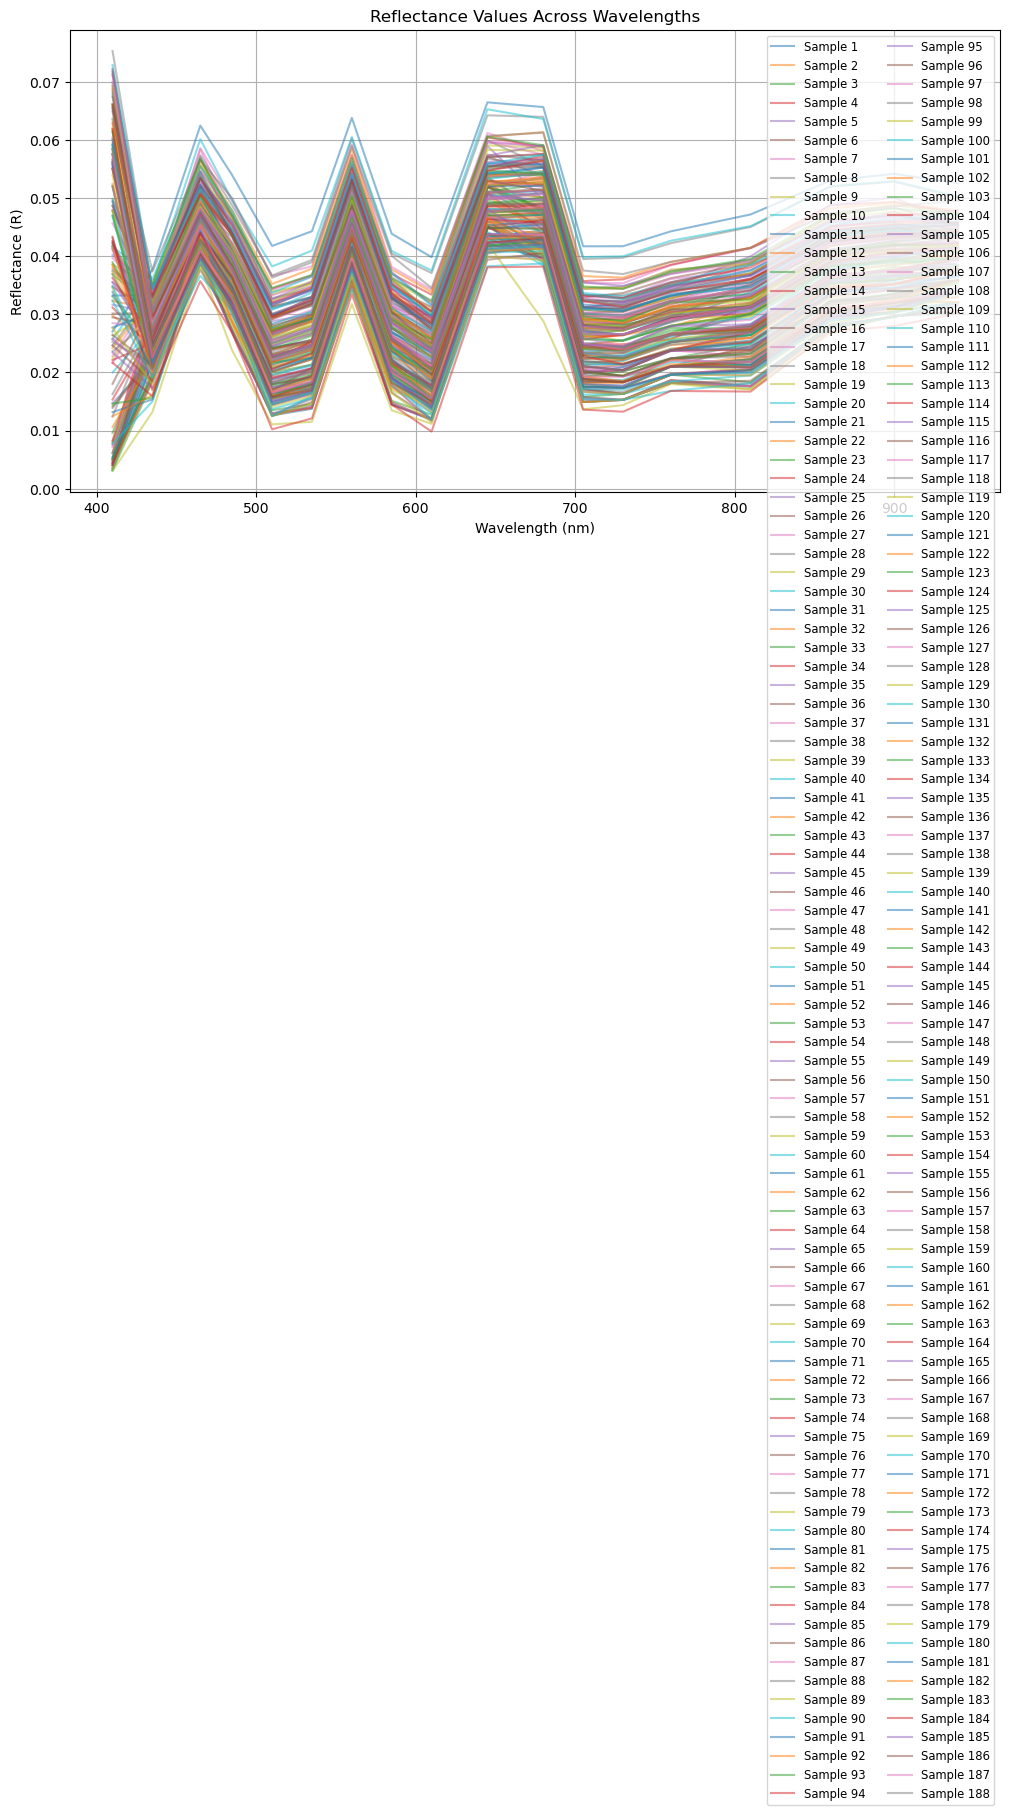

In [3]:
# Import provided 100% Reflectance and Dark Reference values
reflectance_target = np.array([9772, 7397, 14881, 6296, 10010, 12828, 14628, 15010, 
                                12518, 8916, 3405, 2280, 982, 714, 2156, 2353, 1252, 530])
dark_reference = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Calculate reflectance for all predictors in X (raw data)
X_reflectance = ( averaged_readings - dark_reference) / (reflectance_target - dark_reference)

# Plot reflectance (R) values for each channel across all samples
plt.figure(figsize=(12, 6))
for i in range(X_reflectance.shape[0]):  # Loop through each sample
    plt.plot(wavelengths, X_reflectance[i, :], label=f'Sample {i + 1}', alpha=0.5)

plt.title("Reflectance Values Across Wavelengths")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (R)")
plt.grid(True)
plt.legend(loc='upper right', fontsize='small', ncol=2)  # Limit legend size
plt.show()

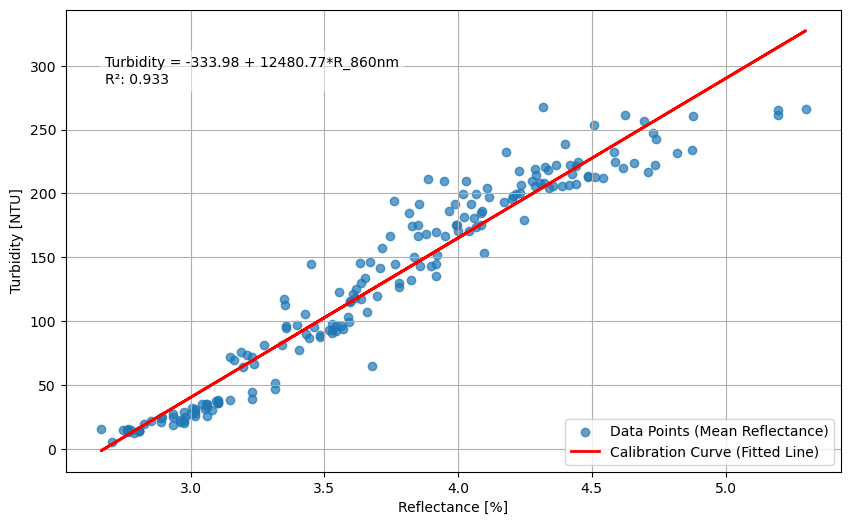

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Extract the reflectance at 860 nm (column index corresponds to the wavelength)
channel_860nm_idx = wavelengths.index(860)
X_860nm_reflectance = X_reflectance[:, channel_860nm_idx].reshape(-1, 1)  # Reshape for a single feature input

# Use the reflectance values (X_reflectance) and turbidity values (Y_actual)
X_calibration = X_860nm_reflectance  # Use all reflectance channels for calibration
Y_calibration = Y  # Corresponding turbidity values

# Fit a linear regression model to obtain the calibration curve
calibration_model = LinearRegression()
calibration_model.fit(X_calibration, Y_calibration)

# Calculate R²
r2_calibration = calibration_model.score(X_calibration, Y_calibration)

# Extract the equation coefficients
coefficients = calibration_model.coef_
intercept = calibration_model.intercept_

# Generate the calibration curve using the fitted model
Y_fitted = calibration_model.predict(X_calibration)

# Generate the equation as a string with normal decimal values
equation_terms = [f"{coeff:.2f}*R_860nm" for i, coeff in enumerate(coefficients)]
equation_text = f"Turbidity = {intercept:.2f} + " + " + ".join(equation_terms)

# Multiply reflectance by 100 to convert to percentage for plotting
mean_reflectance_percentage = np.mean(X_calibration * 100, axis=1)

# Visualize the calibration curve
plt.figure(figsize=(10, 6))

# Plot scatter points (Reflectance vs Turbidity)
plt.scatter(mean_reflectance_percentage, Y_calibration, alpha=0.7, label="Data Points (Mean Reflectance)")

# Plot the fitted calibration curve
plt.plot(mean_reflectance_percentage, Y_fitted, 'r-', linewidth=2, label="Calibration Curve (Fitted Line)")

# Display equation and R² on the plot
metrics_text = f"{equation_text}\nR²: {r2_calibration:.3f}"
plt.text(0.05, 0.90, metrics_text, fontsize=10, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.5, color='white'))

# Add labels, legend, and title
plt.xlabel("Reflectance [%]")
plt.ylabel("Turbidity [NTU]")
#plt.title("Calibration Curve: Reflectance vs Turbidity")
plt.legend(loc="lower right")  # Move the legend to the bottom-right corner
plt.grid(True)
plt.show()



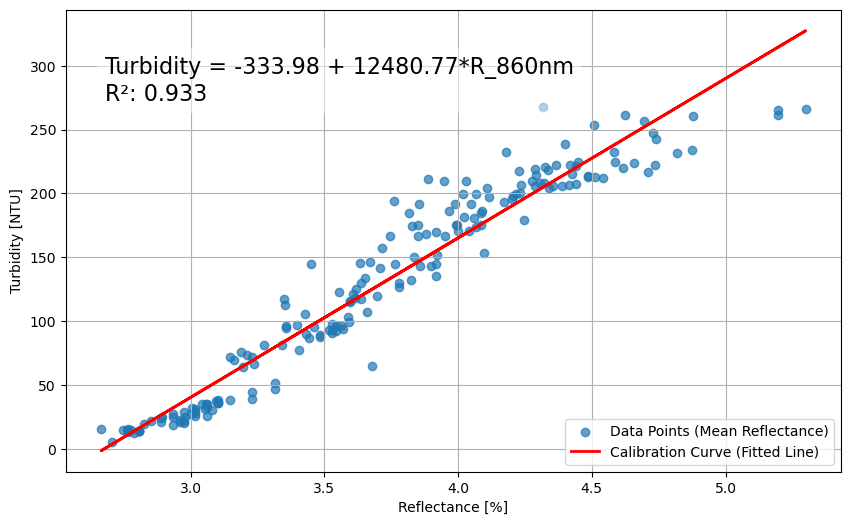

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Extract the reflectance at 860 nm (column index corresponds to the wavelength)
channel_860nm_idx = wavelengths.index(860)
X_860nm_reflectance = X_reflectance[:, channel_860nm_idx].reshape(-1, 1)  # Reshape for a single feature input

# Use the reflectance values (X_reflectance) and turbidity values (Y_actual)
X_calibration = X_860nm_reflectance  # Use reflectance at 860 nm for calibration
Y_calibration = Y  # Corresponding turbidity values

# Fit a linear regression model to obtain the calibration curve
calibration_model = LinearRegression()
calibration_model.fit(X_calibration, Y_calibration)

# Calculate R²
r2_calibration = calibration_model.score(X_calibration, Y_calibration)

# Extract the equation coefficients
coefficients = calibration_model.coef_
intercept = calibration_model.intercept_

# Generate the calibration curve using the fitted model
Y_fitted = calibration_model.predict(X_calibration)


# Generate the equation as a string with normal decimal values
equation_terms = [f"{coeff:.2f}*R_860nm" for i, coeff in enumerate(coefficients)]
equation_text = f"Turbidity = {intercept:.2f} + " + " + ".join(equation_terms)

# Multiply reflectance by 100 to convert to percentage for plotting
mean_reflectance_percentage = np.mean(X_calibration * 100, axis=1)

# Visualize the calibration curve
plt.figure(figsize=(10, 6))

# Plot scatter points (Reflectance vs Turbidity)
plt.scatter(mean_reflectance_percentage, Y_calibration, alpha=0.7, label="Data Points (Mean Reflectance)")

# Plot the fitted calibration curve
plt.plot(mean_reflectance_percentage, Y_fitted, 'r-', linewidth=2, label="Calibration Curve (Fitted Line)")

# Display equation, R², and p-value on the plot
metrics_text = f"{equation_text}\nR²: {r2_calibration:.3f}"
plt.text(0.05, 0.90, metrics_text, fontsize=16, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.5, color='white'))

# Add labels, legend, and title
plt.xlabel("Reflectance [%]")
plt.ylabel("Turbidity [NTU]")
#plt.title("Calibration Curve: Reflectance vs Turbidity")
plt.legend(loc="lower right")  # Move the legend to the bottom-right corner
plt.grid(True)
plt.show()


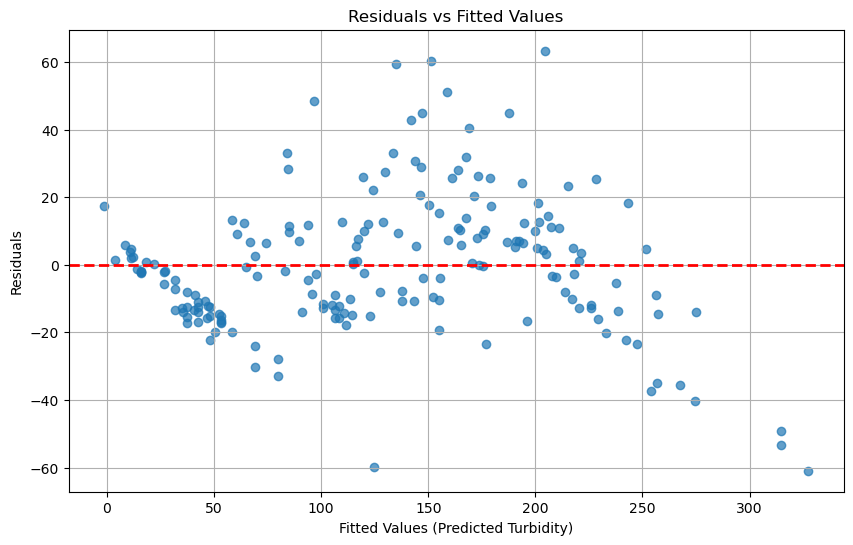

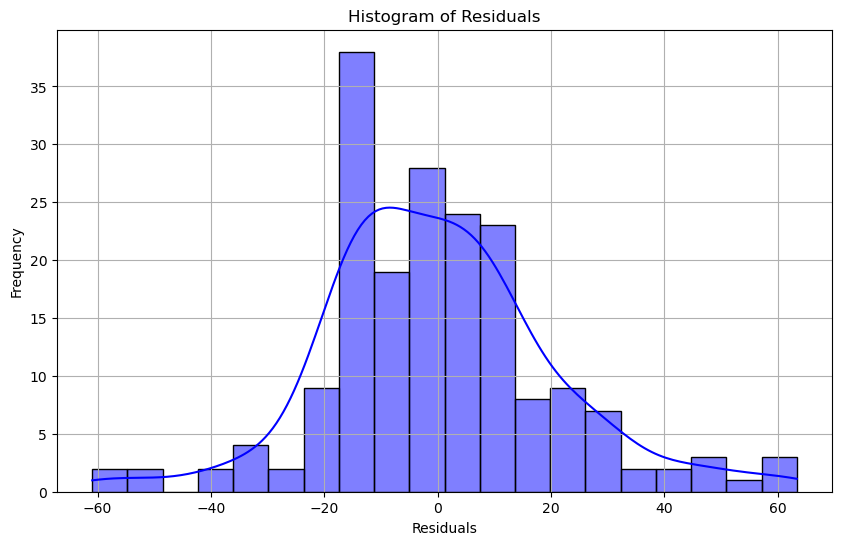

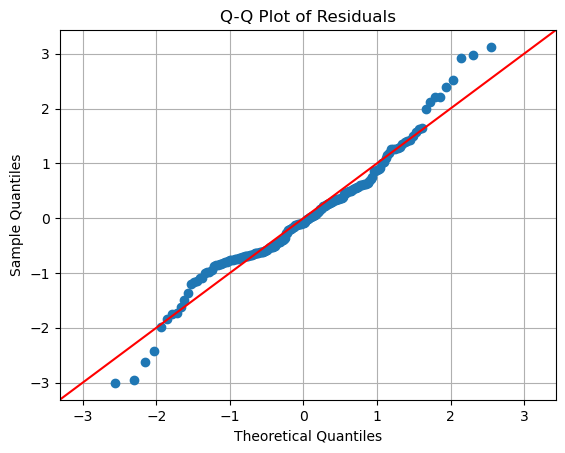

Shapiro-Wilk Test: Statistic=0.969, p-value=0.000
Residuals do not appear to be normally distributed (reject H0).


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Assuming `X_single_channel` and `Y_calibration` were used in your single linear regression

# Calculate residuals (difference between actual and predicted values)
Y_predicted = calibration_model.predict(X_calibration)
residuals = Y_calibration - Y_predicted

# 1. Residuals vs Fitted Values Plot (Linearity and Homoscedasticity)
plt.figure(figsize=(10, 6))
plt.scatter(Y_predicted, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values (Predicted Turbidity)")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

# 2. Histogram of Residuals (Normality)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=20, color='blue')
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 3. Q-Q Plot for Normality
import statsmodels.api as sm
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.grid(True)
plt.show()

# 4. Shapiro-Wilk Test for Normality
shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistic={shapiro_test.statistic:.3f}, p-value={shapiro_test.pvalue:.3f}")
if shapiro_test.pvalue > 0.05:
    print("Residuals appear to be normally distributed (fail to reject H0).")
else:
    print("Residuals do not appear to be normally distributed (reject H0).")


860nm LR with 10-fold Cross-validation

Average R²: 0.931
Average RMSE: 20.183


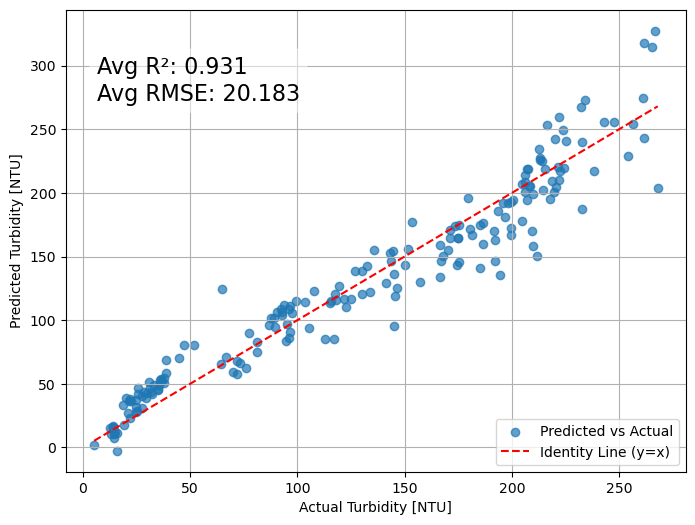

In [7]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Extract reflectance at 860 nm
channel_860nm_idx = wavelengths.index(860)
X_860nm_reflectance = X_reflectance[:, channel_860nm_idx].reshape(-1, 1)  # Reshape for single feature
Y_actual = Y  # The corresponding turbidity values

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics for each fold
r2_scores = []
rmse_scores = []
nse_scores = []

# Store predictions and actual values for visualization
all_predictions = np.array([])
all_actuals = np.array([])

# Perform 10-fold cross-validation
for train_index, test_index in kf.split(X_860nm_reflectance):
    # Split data into training and testing sets
    X_train, X_test = X_860nm_reflectance[train_index], X_860nm_reflectance[test_index]
    Y_train, Y_test = Y_actual[train_index], Y_actual[test_index]

    # Train the model
    model = LinearRegression()
    model.fit(X_train, Y_train)

    # Predict on the test set
    Y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    nse = 1 - (sum((Y_test - Y_pred) ** 2) / sum((Y_test - np.mean(Y_test)) ** 2))

    # Append metrics for this fold
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    nse_scores.append(nse)

    # Collect predictions and actual values
    all_predictions = np.concatenate([all_predictions, Y_pred])
    all_actuals = np.concatenate([all_actuals, Y_test])

# Calculate average metrics across all folds
avg_r2 = np.mean(r2_scores)
avg_rmse = np.mean(rmse_scores)
avg_nse = np.mean(nse_scores)

# Print the evaluation metrics
print(f"Average R²: {avg_r2:.3f}")
print(f"Average RMSE: {avg_rmse:.3f}")

# Visualize predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(all_actuals, all_predictions, alpha=0.7, label="Predicted vs Actual")
plt.plot([min(all_actuals), max(all_actuals)], [min(all_actuals), max(all_actuals)], 'r--', label="Identity Line (y=x)")

# Adding text for performance metrics
metrics_text = f"Avg R²: {avg_r2:.3f}\nAvg RMSE: {avg_rmse:.3f}"
plt.text(0.05, 0.90, metrics_text, fontsize=16, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.5, color='white'))

# Set plot labels and title
plt.xlabel("Actual Turbidity [NTU]")
plt.ylabel("Predicted Turbidity [NTU]")
#plt.title("Predicted vs Actual Turbidity")
plt.legend(loc="lower right")  # Move the legend to the bottom-right corner
plt.grid(True)
plt.show()